<a href="https://colab.research.google.com/github/El-amin/NaijaCXR-VLM/blob/main/NaijaCXR_VLM__MedGemma_4b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U git+https://github.com/huggingface/transformers.git
!pip install -U accelerate bitsandbytes peft dataset

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-3_uxmbow
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-3_uxmbow
  Resolved https://github.com/huggingface/transformers.git to commit 59b9cb06f4a19c6d6601cb3e96c018f170ff6808
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.0/521.0 kB 18.9 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-5.0.0.dev0-py3-none-any.whl size=11030121 sha256=0f6480f1e368eb0f1659d0ea9a4a8d7e8609b7beb91f9bf318852e2ccd58727d
  Stored in directory: /tmp/pip-ephem-wheel-cache-japuwz75/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-h

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get('Medgemma')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!unzip /content/drive/MyDrive/RSFUTH_CXR.zip -d /content/

Archive:  /content/drive/MyDrive/RSFUTH_CXR.zip
   creating: /content/RSFUTH_CXR/
  inflating: /content/__MACOSX/._RSFUTH_CXR  
   creating: /content/RSFUTH_CXR/P00023/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00023  
   creating: /content/RSFUTH_CXR/P00024/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00024  
   creating: /content/RSFUTH_CXR/P00012/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00012  
   creating: /content/RSFUTH_CXR/P00015/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00015  
   creating: /content/RSFUTH_CXR/P00041/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00041  
   creating: /content/RSFUTH_CXR/P00079/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00079  
   creating: /content/RSFUTH_CXR/P00046/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00046  
   creating: /content/RSFUTH_CXR/P00084/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00084  
   creating: /content/RSFUTH_CXR/P00070/
  inflating: /content/__MACOSX/RSFUTH_CXR/._P00070  
   creating: /content/RSFU

In [ ]:
!unzip /content/drive/MyDrive/Seleccted_mimic_CXR_images.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/Seleccted_mimic_CXR_images/00e55019-45ba2cfc-4a001f73-4ec36262-71cf86ad.jpg  
  inflating: /content/__MACOSX/Seleccted_mimic_CXR_images/._00e55019-45ba2cfc-4a001f73-4ec36262-71cf86ad.jpg  
  inflating: /content/Seleccted_mimic_CXR_images/11bcffc7-e7af9fd9-28ff7842-07278147-8d3a58bd.jpg  
  inflating: /content/__MACOSX/Seleccted_mimic_CXR_images/._11bcffc7-e7af9fd9-28ff7842-07278147-8d3a58bd.jpg  
  inflating: /content/Seleccted_mimic_CXR_images/f4d85d2d-754648de-3f1b90a9-b6d98a97-dcd0367f.jpg  
  inflating: /content/__MACOSX/Seleccted_mimic_CXR_images/._f4d85d2d-754648de-3f1b90a9-b6d98a97-dcd0367f.jpg  
  inflating: /content/Seleccted_mimic_CXR_images/a32990db-01db76c5-5cd8c181-a1ee08ab-d7c0768c.jpg  
  inflating: /content/__MACOSX/Seleccted_mimic_CXR_images/._a32990db-01db76c5-5cd8c181-a1ee08ab-d7c0768c.jpg  
  inflating: /content/Seleccted_mimic_CXR_images/ec7a9e96-eb7247bc-4f50cb80-5a3ebf0f-db991c5d.jpg  
  inf

**Adversarial Domain Adaptation**

In [ ]:
from transformers import AutoModel, AutoProcessor
from peft import LoraConfig, get_peft_model

# 1. Load the Official SigLIP Encoder from MedGemma
# MedGemma uses 'google/siglip-so400m-patch14-384' typically
SIGLIP_ID = "google/siglip-so400m-patch14-384"

processor = AutoProcessor.from_pretrained(SIGLIP_ID)
vision_tower = AutoModel.from_pretrained(SIGLIP_ID)

# 2. Freeze the Base Model
for param in vision_tower.parameters():
    param.requires_grad = False

# 3. Inject LoRA Adapters
# We target query and value projections in the Transformer
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

vision_tower = get_peft_model(vision_tower, peft_config)
vision_tower.print_trainable_parameters()
# Result: You will train ~0.5% of params (very memory efficient!)

vision_tower.to("cuda")

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

trainable params: 3,981,312 || all params: 881,941,810 || trainable%: 0.4514


PeftModel(
  (base_model): LoraModel(
    (model): SiglipModel(
      (text_model): SiglipTextTransformer(
        (embeddings): SiglipTextEmbeddings(
          (token_embedding): Embedding(32000, 1152)
          (position_embedding): Embedding(64, 1152)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-26): 27 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (v_proj): lora.Linear(
                  (base_layer): Linear(in_features=1152, out_features=1152, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1152, out_features=16, bias=False)
                  )
                

In [ ]:
from transformers import SiglipVisionModel, AutoProcessor # Changed AutoModel to SiglipVisionModel

from peft import LoraConfig, get_peft_model

# 1. Load the Official SigLIP Encoder from MedGemma
# MedGemma uses 'google/siglip-so400m-patch14-384' typically
SIGLIP_ID = "google/siglip-so400m-patch14-384"

processor = AutoProcessor.from_pretrained(SIGLIP_ID)
vision_tower = AutoModel.from_pretrained(SIGLIP_ID)

# 2. Freeze the Base Model
for param in vision_tower.parameters():
    param.requires_grad = False

# 3. Inject LoRA Adapters
# We target query and value projections in the Transformer
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

# =========================================================
# 4. SETUP SIGLIP VISION TOWER (Corrected)
# =========================================================
print("Loading SigLIP Vision Model...")
processor = AutoProcessor.from_pretrained(SIGLIP_ID)

# FIX: Load ONLY the Vision Encoder
vision_tower = SiglipVisionModel.from_pretrained(SIGLIP_ID)

# A. Freeze Base Model
for param in vision_tower.parameters():
    param.requires_grad = False

# B. Inject LoRA
# The module names are correct for the vision encoder too
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none"
)

vision_tower = get_peft_model(vision_tower, peft_config)
vision_tower.print_trainable_parameters()
vision_tower.to("cuda")

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Loading SigLIP Vision Model...


Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.weight  

trainable params: 2,985,984 || all params: 431,211,584 || trainable%: 0.6925


PeftModel(
  (base_model): LoraModel(
    (model): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
          (position_embedding): Embedding(729, 1152)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-26): 27 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=1152, out_features=1152, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1152, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDic

In [ ]:
#Standardize NaijaCXR Reports.CSV

import pandas as pd

naija = pd.read_csv("/content/New_CXR_Labels.csv")

naija_std = naija.rename(columns={
    "PID": "image_id",
    "Report": "findings",
    "Impression": "impression"
})

naija_std = naija_std[["image_id", "findings", "impression"]]
naija_std["domain"] = 1   # target

naija_std.to_csv("naija_standardized.csv", index=False)


In [ ]:
#Standardize MimicCXR Reports.CSV

mimic = pd.read_csv("/content/Seleccted_mimic_CXR_images/My_Mimic_cxr_reports.csv")

mimic_std = mimic.rename(columns={
    "dicom_id": "image_id",
    "findings": "findings",
    "impression": "impression"
})

# Keep only what we need
mimic_std = mimic_std[["image_id", "findings", "impression"]]

mimic_std["domain"] = 0   # source domain

mimic_std.to_csv("mimic_standardized.csv", index=False)

In [ ]:
#Adapation with warm-up

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import SiglipVisionModel, AutoProcessor
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
from PIL import Image
import itertools

# =========================================================
# 1. CONFIGURATION
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16            # Reduce to 8 if you get OOM
WARMUP_EPOCHS = 3          # Train Discriminator only
TOTAL_EPOCHS = 15          # Total training epochs
LR_LORA = 2e-4             # Learning Rate for Vision Adapter
LR_DISC = 2e-4             # Learning Rate for Discriminator
SIGLIP_ID = "google/siglip-so400m-patch14-384"

# =========================================================
# 2. DATASET (Uses Processor)
# =========================================================
class SigLIPDomainDataset(Dataset):
    def __init__(self, csv_path, image_root, domain_label, processor, layout="flat"):
        self.df = pd.read_csv(csv_path)
        self.image_root = image_root
        self.domain_label = domain_label
        self.processor = processor
        self.layout = layout

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["image_id"])

        # Path Logic
        if self.layout == "flat":
            img_path = os.path.join(self.image_root, image_id + ".jpg")
        else: # Nested
            img_path = os.path.join(self.image_root, image_id, image_id + ".jpg")

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new('RGB', (384, 384), color='black') # Fallback

        # PROCESSOR: Handles Resize (384), Normalize
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs.pixel_values.squeeze(0) # [3, 384, 384]

        domain = torch.tensor(self.domain_label, dtype=torch.float)

        # Fake task label (Replace with actual labels if you have them)
        task_label = torch.zeros(1)

        return pixel_values, domain, task_label

# =========================================================
# 3. GRADIENT REVERSAL LAYER
# =========================================================
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

def grl(x, lambda_):
    return GradientReversal.apply(x, lambda_)

# =========================================================
# 4. SETUP SIGLIP + LoRA
# =========================================================
print("Loading SigLIP Vision Model...")
processor = AutoProcessor.from_pretrained(SIGLIP_ID)
vision_tower = SiglipVisionModel.from_pretrained(SIGLIP_ID)

# A. Freeze Base Model
for param in vision_tower.parameters():
    param.requires_grad = False

# B. Inject LoRA
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.05,
    bias="none"
)

vision_tower = get_peft_model(vision_tower, peft_config)
vision_tower.to(DEVICE)
print("✅ LoRA Injected.")

# =========================================================
# 5. DISCRIMINATOR
# =========================================================
FEATURE_DIM = vision_tower.config.hidden_size

class DomainDiscriminator(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

discriminator = DomainDiscriminator(FEATURE_DIM).to(DEVICE)
task_classifier = nn.Linear(FEATURE_DIM, 1).to(DEVICE)

# =========================================================
# 6. OPTIMIZERS & DATA LOADERS
# =========================================================
# Optimizer for LoRA + Task Head
optimizer_gen = torch.optim.AdamW(
    list(vision_tower.parameters()) + list(task_classifier.parameters()),
    lr=LR_LORA
)
# Optimizer for Discriminator
optimizer_disc = torch.optim.AdamW(discriminator.parameters(), lr=LR_DISC)

criterion = nn.BCEWithLogitsLoss()

# Loaders
mimic_ds = SigLIPDomainDataset("mimic_standardized.csv", "/content/Seleccted_mimic_CXR_images", 0, processor, "flat")
naija_ds = SigLIPDomainDataset("naija_standardized.csv", "/content/RSFUTH_CXR", 1, processor, "nested")

mimic_loader = DataLoader(mimic_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
naija_loader = DataLoader(naija_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# =========================================================
# 7. TRAINING LOOP (WITH WARM-UP)
# =========================================================
# ... (Configuration and Loaders remain the same) ...

print(f"Starting Training with {WARMUP_EPOCHS} Warm-Up Epochs (Fixed)...")

for epoch in range(TOTAL_EPOCHS):

    # --- PHASE CHECK ---
    is_warmup = epoch < WARMUP_EPOCHS
    phase_name = "WARM-UP (Disc Only)" if is_warmup else "ADVERSARIAL (Joint)"

    # Set Modes
    discriminator.train()
    if is_warmup:
        vision_tower.eval()
        for p in vision_tower.parameters(): p.requires_grad = False
        for p in discriminator.parameters(): p.requires_grad = True
    else:
        vision_tower.train()
        for n, p in vision_tower.named_parameters():
            if "lora" in n: p.requires_grad = True

    # Dynamic Lambda
    if is_warmup:
        lambda_adv = 0.0
    else:
        p = (epoch - WARMUP_EPOCHS) / (TOTAL_EPOCHS - WARMUP_EPOCHS)
        lambda_adv = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0

    # Dataset Cycling
    if len(mimic_loader) > len(naija_loader):
        loader = zip(mimic_loader, itertools.cycle(naija_loader))
        total_steps = len(mimic_loader)
    else:
        loader = zip(itertools.cycle(mimic_loader), naija_loader)
        total_steps = len(naija_loader)

    loop = tqdm(loader, total=total_steps, desc=f"Ep [{epoch+1}/{TOTAL_EPOCHS}] {phase_name}")

    running_d_loss = 0.0

    for (img_s, d_s, label_s), (img_t, d_t, _) in loop:
        img_s, d_s, label_s = img_s.to(DEVICE), d_s.to(DEVICE), label_s.to(DEVICE)
        img_t, d_t = img_t.to(DEVICE), d_t.to(DEVICE)

        # Zero Gradients for BOTH optimizers at start
        optimizer_gen.zero_grad()
        optimizer_disc.zero_grad()

        imgs_all = torch.cat([img_s, img_t], dim=0)

        # 1. Forward SigLIP
        if is_warmup:
            with torch.no_grad():
                outputs = vision_tower(pixel_values=imgs_all)
                seq_output = outputs.last_hidden_state
        else:
            outputs = vision_tower(pixel_values=imgs_all)
            seq_output = outputs.last_hidden_state

        # 2. Global Pooling
        features_all = seq_output.mean(dim=1)
        feat_s = features_all[:len(img_s)]

        # 3. Calculate Losses

        # A) Domain Loss (Always calculated)
        feat_adv = grl(features_all, lambda_adv)
        d_pred = discriminator(feat_adv)
        d_labels = torch.cat([d_s, d_t], dim=0)
        loss_domain = criterion(d_pred, d_labels)

        # 4. Backward & Step (Branching Logic)
        if is_warmup:
            # Phase 1: Only update Discriminator
            loss_domain.backward()
            optimizer_disc.step()
        else:
            # Phase 2: Joint Update (Single Backward Pass)
            # Calculate Task Loss
            task_pred = task_classifier(feat_s)
            loss_task = criterion(task_pred, label_s)

            # Combine Losses
            # The GRL layer inside 'feat_adv' handles the gradient reversal automatically.
            loss_total = loss_task + loss_domain

            loss_total.backward()

            # Update Both
            optimizer_gen.step()
            optimizer_disc.step()

        running_d_loss += loss_domain.item()
        loop.set_postfix(d_loss=loss_domain.item())

    # Save Checkpoint
    save_path = f"siglip_lora_epoch_{epoch+1}"
    vision_tower.save_pretrained(save_path)
    print(f"Epoch {epoch+1} Avg D-Loss: {running_d_loss/total_steps:.4f}")

Loading SigLIP Vision Model...


Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj

✅ LoRA Injected.
Starting Training with 3 Warm-Up Epochs (Fixed)...


Ep [1/10] WARM-UP (Disc Only): 100%|██████████| 164/164 [11:34<00:00,  4.23s/it, d_loss=0.000421]


...

Epoch 8 Avg D-Loss: 0.8153


Ep [9/10] ADVERSARIAL (Joint): 100%|██████████| 164/164 [15:34<00:00,  5.70s/it, d_loss=0.691]


Epoch 9 Avg D-Loss: 0.7609


Ep [10/10] ADVERSARIAL (Joint): 100%|██████████| 164/164 [15:37<00:00,  5.72s/it, d_loss=0.733]


Epoch 10 Avg D-Loss: 0.7915


In [ ]:
#Saving Adapted encoder to drive
from google.colab import drive
import shutil
import os

# 2. Define Source and Destination
source_folder = "siglip_lora_epoch_10"  # The folder in Colab
destination_folder = "/content/drive/MyDrive/NaijaCXR_Project/siglip_lora_epoch_15" # Folder in Drive

# 3. Copy the folder
if os.path.exists(destination_folder):
    print(f"Warning: {destination_folder} already exists. Removing old version...")
    shutil.rmtree(destination_folder)

print(f"Copying to Google Drive...")
shutil.copytree(source_folder, destination_folder)
print(f"✅ Success! Adapter saved to: {destination_folder}")

Copying to Google Drive...
✅ Success! Adapter saved to: /content/drive/MyDrive/NaijaCXR_Project/siglip_lora_epoch_15


Loading Models...
Models Loaded!

--- Processing Baseline (Before) ---


Naija Baseline: 100%|██████████| 7/7 [01:25<00:00, 12.23s/it]



--- Processing Adapted (After) ---


Naija Adapted: 100%|██████████| 7/7 [01:27<00:00, 12.46s/it]


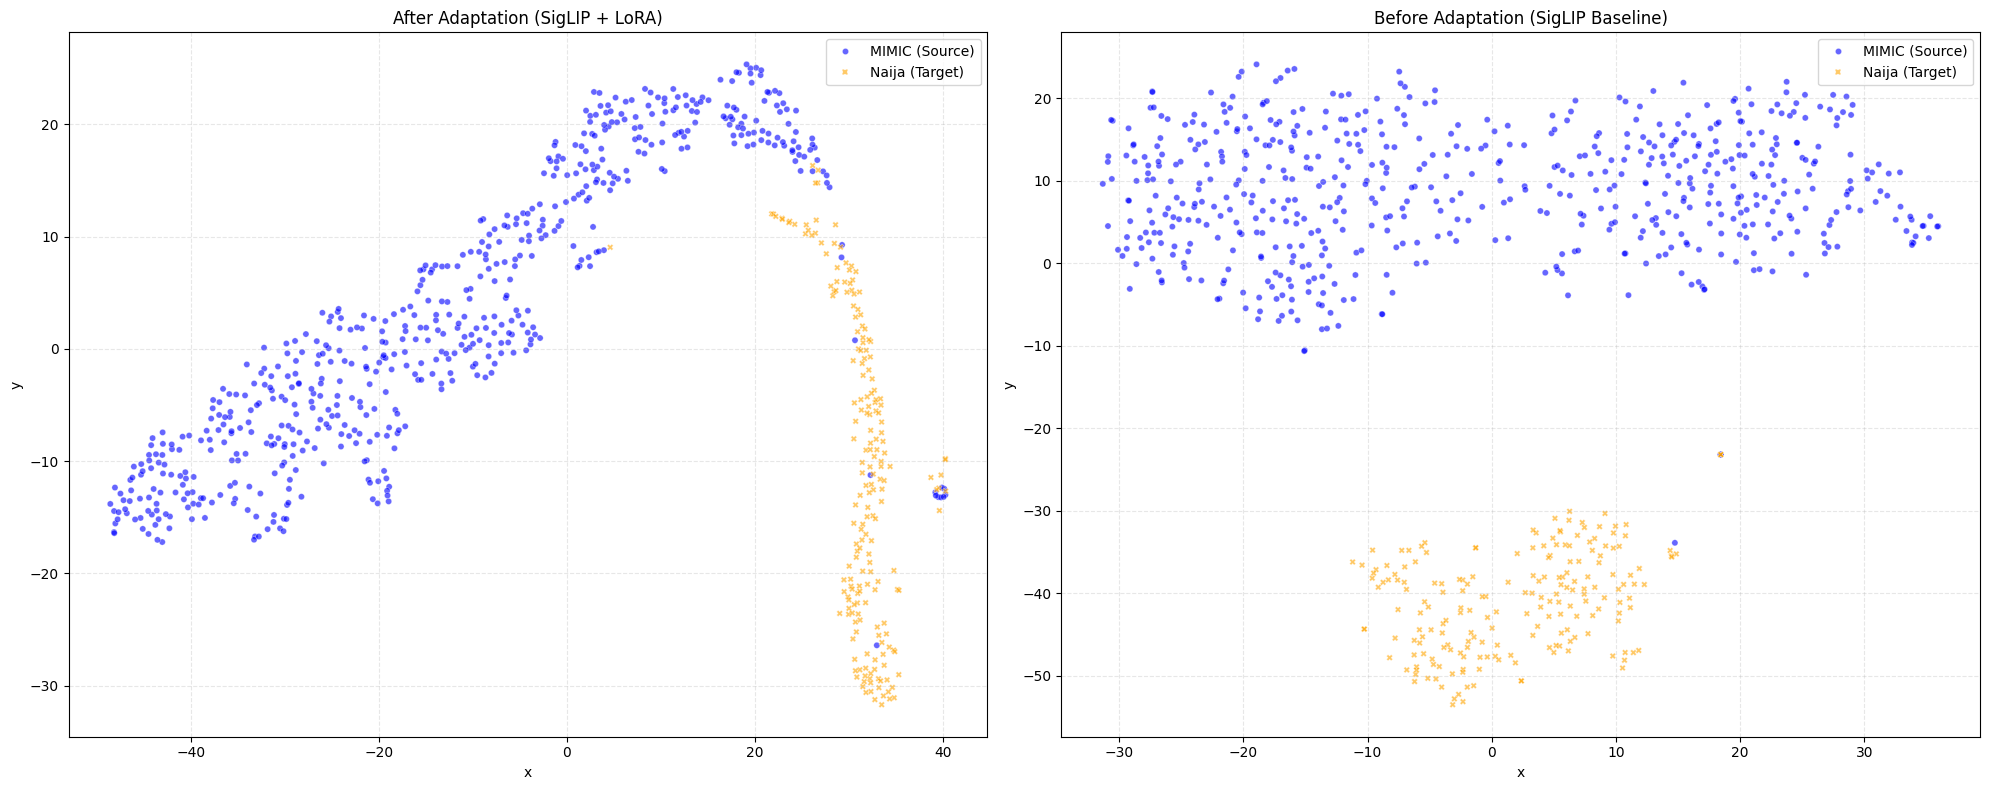

In [ ]:
#PLotting tsne to ensure the vision encoder is adapted to NairaCXR.

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from transformers import SiglipVisionModel, AutoProcessor
from peft import PeftModel, PeftConfig
from PIL import Image
import os
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_MODEL_ID = "google/siglip-so400m-patch14-384"

# Path to your saved adapter folder (Change this to your best epoch!)
ADAPTER_PATH = "/content/drive/MyDrive/NaijaCXR_Project/siglip_lora_epoch_15"

# Data Paths
MIMIC_CSV = "mimic_standardized.csv"
MIMIC_ROOT = "/content/Seleccted_mimic_CXR_images"
NAIJA_CSV = "naija_standardized.csv"
NAIJA_ROOT = "/content/RSFUTH_CXR"

# ==========================================
# 2. DATASET CLASS (Simplified for Inference)
# ==========================================
class InferenceDataset(Dataset):
    def __init__(self, csv_path, image_root, processor, layout="flat", limit=None):
        self.df = pd.read_csv(csv_path)
        if limit:
            self.df = self.df.sample(n=min(limit, len(self.df)), random_state=42)
        self.image_root = image_root
        self.processor = processor
        self.layout = layout

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["image_id"])

        if self.layout == "flat":
            img_path = os.path.join(self.image_root, image_id + ".jpg")
        else:
            img_path = os.path.join(self.image_root, image_id, image_id + ".jpg")

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new('RGB', (384, 384), color='black')

        inputs = self.processor(images=image, return_tensors="pt")
        return inputs.pixel_values.squeeze(0)

# ==========================================
# 3. HELPER: FEATURE EXTRACTION
# ==========================================
def extract_features(model, loader, desc="Extracting"):
    model.eval()
    features = []

    with torch.no_grad():
        for imgs in tqdm(loader, desc=desc):
            imgs = imgs.to(DEVICE)

            # Forward Pass
            outputs = model(pixel_values=imgs)

            # Global Average Pooling [Batch, Patches, Dim] -> [Batch, Dim]
            # We take the mean of all patch tokens to represent the image
            feats = outputs.last_hidden_state.mean(dim=1)

            features.append(feats.cpu().numpy())

    return np.vstack(features)

# ==========================================
# 4. LOAD MODELS
# ==========================================
print("Loading Models...")
processor = AutoProcessor.from_pretrained(BASE_MODEL_ID)

# --- A. Load Baseline (Before Adaptation) ---
# Pure SigLIP without adapters
model_baseline = SiglipVisionModel.from_pretrained(BASE_MODEL_ID)
model_baseline.to(DEVICE)

# --- B. Load Adapted (After Adaptation) ---
# Base SigLIP + Your LoRA Adapters
model_adapted = SiglipVisionModel.from_pretrained(BASE_MODEL_ID)
model_adapted = PeftModel.from_pretrained(model_adapted, ADAPTER_PATH)
model_adapted.to(DEVICE)

print("Models Loaded!")

# ==========================================
# 5. EXTRACT FEATURES
# ==========================================
SAMPLES = 600 # Number of images per domain to plot (keep it balanced)

# Create Loaders
mimic_ds = InferenceDataset(MIMIC_CSV, MIMIC_ROOT, processor, "flat", limit=SAMPLES)
naija_ds = InferenceDataset(NAIJA_CSV, NAIJA_ROOT, processor, "nested", limit=SAMPLES)

mimic_loader = DataLoader(mimic_ds, batch_size=32, shuffle=False)
naija_loader = DataLoader(naija_ds, batch_size=32, shuffle=False)

# Extract for Baseline
print("\n--- Processing Baseline (Before) ---")
mimic_feats_b = extract_features(model_baseline, mimic_loader, "MIMIC Baseline")
naija_feats_b = extract_features(model_baseline, naija_loader, "Naija Baseline")

# Extract for Adapted
print("\n--- Processing Adapted (After) ---")
mimic_feats_a = extract_features(model_adapted, mimic_loader, "MIMIC Adapted")
naija_feats_a = extract_features(model_adapted, naija_loader, "Naija Adapted")

# ==========================================
# 6. COMPUTE t-SNE AND PLOT
# ==========================================
def plot_tsne(mimic_f, naija_f, title, ax):
    # Combine
    X = np.vstack([mimic_f, naija_f])
    y = np.hstack([np.zeros(len(mimic_f)), np.ones(len(naija_f))]) # 0=MIMIC, 1=Naija

    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X)

    # Plot
    df = pd.DataFrame({
        "x": X_embedded[:, 0], "y": X_embedded[:, 1],
        "Domain": ["MIMIC (Source)" if label==0 else "Naija (Target)" for label in y]
    })

    sns.scatterplot(
        data=df, x="x", y="y", hue="Domain", style="Domain",
        alpha=0.6, s=20, ax=ax,
        palette={'MIMIC (Source)': 'blue', 'Naija (Target)': 'orange'}
    )
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

# Generate Figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_tsne(mimic_feats_b, naija_feats_b, "Before Adaptation (SigLIP Baseline)", axes[1])
plot_tsne(mimic_feats_a, naija_feats_a, "After Adaptation (SigLIP + LoRA)", axes[0])

plt.tight_layout()
plt.show()

**Training VLM Phase with DA Invariant Featuures**

In [ ]:
#New Idea 08/01/2026
import torch
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    SiglipVisionModel
)
from peft import PeftModel, LoraConfig, get_peft_model

# 1. CONFIGURATION
MODEL_ID = "google/medgemma-4b-it"
SIGLIP_ID = "google/siglip-so400m-patch14-384"
ADAPTER_PATH = "/content/drive/MyDrive/NaijaCXR_Project/siglip_lora_epoch_15"

print(f"🏥 Initializing {MODEL_ID}...")

# 2. LOAD 4-BIT MODEL (LLM + Projector)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
)

# =========================================================
# 3. OFFLINE MERGE (Vision Tower)
# =========================================================
print("🛠️ Preparing Vision Tower separately (BFloat16)...")

clean_vision_tower = SiglipVisionModel.from_pretrained(
    SIGLIP_ID,
    torch_dtype=torch.bfloat16
)

# Apply your NaijaCXR adapter and merge
clean_vision_tower = PeftModel.from_pretrained(clean_vision_tower, ADAPTER_PATH)
print("   Merging adapter weights...")
clean_vision_tower = clean_vision_tower.merge_and_unload()

# Ensure it's on the same device as the main model's vision tower would be
# (Safe to put on GPU 0 for single-GPU setups)
clean_vision_tower.to("cuda")

# =========================================================
# 4. TRANSPLANT
# =========================================================
print("🔌 Transplanting merged tower into MedGemma...")

# CRITICAL: Verify the path. For PaliGemma-based models, it is often 'model.vision_tower'
# We use a try/except block to handle potential wrapper naming variations
try:
    # Standard PaliGemma/MedGemma structure
    if hasattr(model, "vision_tower"):
        model.vision_tower = clean_vision_tower
    elif hasattr(model.model, "vision_tower"):
        model.model.vision_tower = clean_vision_tower
    else:
        raise AttributeError("Could not find 'vision_tower' in model attributes.")
except AttributeError as e:
    print(f"⚠️ Error locating vision tower: {e}")
    print("Available keys:", model)
    raise

print("✅ Vision Encoder updated (BFloat16)!")

# =========================================================
# 5. ADD LoRA (Including Projector!)
# =========================================================

# A. Locate the Projector
# Depending on the specific MedGemma version, it might be at different depths.
projector = None
if hasattr(model, "multi_modal_projector"):
    projector = model.multi_modal_projector
elif hasattr(model.model, "multi_modal_projector"):
    projector = model.model.multi_modal_projector
else:
    raise ValueError("Could not find 'multi_modal_projector' in model!")

#  De-quantize the Projector (Critical Step)
# We cannot train a 4-bit layer directly. We must cast it to BFloat16.
print("🔓 Unfreezing and de-quantizing the Projector...")
projector.to(dtype=torch.bfloat16)
projector.train()
for param in projector.parameters():
    param.requires_grad = True


# =========================================================
# 5.b FIX ARCHITECTURE MISMATCH (Critical)
# =========================================================
print("🔧 Patching Model Configuration...")

# 1. Update Config to match your 384px encoder
model.config.vision_config.image_size = 384
model.config.vision_config.patch_size = 14

# 2. Patch the Projector Pooling Layer
# SigLIP-384 outputs a 27x27 grid. The original AvgPool(4x4) requires a multiple of 4.
# We replace pooling with Identity to pass all 729 tokens to the LLM (High Fidelity).
if hasattr(projector, "avg_pool"):
    print(f"   Removing incompatible pooling layer: {projector.avg_pool}")
    projector.avg_pool = torch.nn.Identity()

# 3. Update Token Count in Config (if present)
# This ensures the processor and model agree on sequence length
if hasattr(model.config.vision_config, "num_image_tokens"):
    # New token count = 27 * 27 = 729
    model.config.vision_config.num_image_tokens = 729
    print(f"   Updated num_image_tokens to {model.config.vision_config.num_image_tokens}")

print("✅ Architecture patched for 384px input (27x27 grid).")

# =========================================================
# C. Configure LoRA for the LLM *only*
# We remove 'multi_modal_projector' from target_modules because we are training it fully.
# We add it to 'modules_to_save' so PEFT knows to save these full weights, not just adapters.

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "v_proj", "k_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    # This tells PEFT: "Don't LoRA this module, but DO save its full updated weights"
    modules_to_save=["multi_modal_projector"],
    task_type="CAUSAL_LM",
    lora_dropout=0.05,
    bias="none"
)

model = get_peft_model(model, lora_config)

print("🚀 Model Ready!")
model.print_trainable_parameters()

# Safety Check: Input Resolution
print("\n⚠️ SAFETY CHECK:")
print(f"Vision Tower Config Image Size: {clean_vision_tower.config.image_size}")
print(f"MedGemma Config Image Size: {model.config.vision_config.image_size}")
if clean_vision_tower.config.image_size != model.config.vision_config.image_size:
    print("🔴 WARNING: Image resolution mismatch! The projector might fail due to token count differences.")

🏥 Initializing google/medgemma-4b-it...


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

🛠️ Preparing Vision Tower separately (BFloat16)...


Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj

   Merging adapter weights...
🔌 Transplanting merged tower into MedGemma...
✅ Vision Encoder updated (BFloat16)!
🔓 Unfreezing and de-quantizing the Projector...
🔧 Patching Model Configuration...
   Removing incompatible pooling layer: AvgPool2d(kernel_size=4, stride=4, padding=0)
✅ Architecture patched for 384px input (27x27 grid).
🚀 Model Ready!
trainable params: 35,738,752 || all params: 4,347,177,792 || trainable%: 0.8221

⚠️ SAFETY CHECK:
Vision Tower Config Image Size: 384
MedGemma Config Image Size: 384


In [ ]:
# =========================================================
# 5.e FORCE UPDATE 'patches_per_image' (The Real Fix)
# =========================================================
print("🕵️  Scanning model for hardcoded 'patches_per_image' attributes...")

# We need to change 64 (896px) to 27 (384px)
# Math: 27 * 27 = 729 tokens.
TARGET_VAL = 27

count = 0
for name, module in model.named_modules():
    # Check if this specific module has the attribute
    if hasattr(module, "patches_per_image"):
        old_val = module.patches_per_image

        # Only update if it looks like the old value (64)
        if old_val == 64:
            print(f"   Found match in: {name}")
            print(f"   └── Changing patches_per_image from {old_val} to {TARGET_VAL}")
            module.patches_per_image = TARGET_VAL
            count += 1

if count == 0:
    print("⚠️ Warning: No 'patches_per_image' attributes found to update. Check your model version.")
else:
    print(f"✅ Updated {count} hardcoded attributes.")


🕵️  Scanning model for hardcoded 'patches_per_image' attributes...
   Found match in: base_model.model.model.multi_modal_projector
   └── Changing patches_per_image from 64 to 27
   Found match in: base_model.model.model.multi_modal_projector.original_module
   └── Changing patches_per_image from 64 to 27
   Found match in: base_model.model.model.multi_modal_projector.modules_to_save.default
   └── Changing patches_per_image from 64 to 27
✅ Updated 3 hardcoded attributes.


In [ ]:
import json
import os

# Configuration
FILES_TO_CLEAN = ["mimic_train.json", "Naija_train.json"]
CLEANED_SUFFIX = "_cleaned.json"

def clean_dataset(filename):
    print(f"🧹 Cleaning {filename}...")

    with open(filename, 'r') as f:
        data = json.load(f)

    clean_data = []
    removed_nan_count = 0
    removed_missing_file_count = 0

    for item in data:
        # 1. Extract the Assistant's response (Ground Truth)
        messages = item.get("messages", [])
        assistant_text = ""
        user_image_path = ""

        for msg in messages:
            if msg["role"] == "assistant":
                assistant_text = msg["content"][0]["text"]
            if msg["role"] == "user":
                # Find image path
                for content in msg["content"]:
                    if content["type"] == "image":
                        user_image_path = content["image"]

        # 2. Check for "nan" (Case insensitive)
        # We look for "nan" appearing as a distinct word or line
        if "\nnan" in assistant_text.lower() or " nan " in assistant_text.lower() or assistant_text.lower().strip() == "nan":
            removed_nan_count += 1
            continue # SKIP this bad sample

        # 3. Check if image file exists (Optional but recommended)
        # Handle MIMIC paths relative to /content/
        full_path = user_image_path
        if "Seleccted_mimic_CXR_images" in user_image_path and not user_image_path.startswith("/"):
             full_path = os.path.join("/content", user_image_path)

        if not os.path.exists(full_path):
            # Uncomment the line below to strictly remove missing files
            # removed_missing_file_count += 1
            # continue
            pass # For now, just warning

        # If it passes checks, keep it
        clean_data.append(item)

    # Save cleaned file
    new_filename = filename.replace(".json", CLEANED_SUFFIX)
    with open(new_filename, 'w') as f:
        json.dump(clean_data, f, indent=2)

    print(f"   Original size: {len(data)}")
    print(f"   Removed 'nan': {removed_nan_count}")
    print(f"   Removed missing files: {removed_missing_file_count}")
    print(f"   ✅ Saved {len(clean_data)} valid samples to {new_filename}\n")
    return new_filename

# Run cleaning
cleaned_files = []
for f_name in FILES_TO_CLEAN:
    if os.path.exists(f_name):
        cleaned_files.append(clean_dataset(f_name))
    else:
        print(f"⚠️ File not found: {f_name}")

print(" 👇 USE THESE FILES FOR TRAINING NOW:")
print(cleaned_files)

🧹 Cleaning mimic_train.json...
   Original size: 1846
   Removed 'nan': 840
   Removed missing files: 0
   ✅ Saved 1006 valid samples to mimic_train_cleaned.json

🧹 Cleaning Naija_train.json...
   Original size: 140
   Removed 'nan': 0
   Removed missing files: 0
   ✅ Saved 140 valid samples to Naija_train_cleaned.json

 👇 USE THESE FILES FOR TRAINING NOW:
['mimic_train_cleaned.json', 'Naija_train_cleaned.json']


In [ ]:
#New fixes
import torch
import torch.nn.functional as F
import types
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    SiglipVisionModel
)
from peft import LoraConfig, get_peft_model, PeftModel
from PIL import Image
import numpy as np

# =========================================================
# 1. CONFIGURATION
# =========================================================
MODEL_ID = "google/medgemma-4b-it"
SIGLIP_ID = "google/siglip-so400m-patch14-384"
ADAPTER_PATH = "/content/drive/MyDrive/NaijaCXR_Project/siglip_lora_epoch_15"

# Target Settings for your Custom Encoder
TARGET_IMAGE_SIZE = 384
TARGET_PATCH_SIZE = 14
# Math: (384/14)^2 = 27*27 = 729 tokens
TARGET_TOKENS = 729
OLD_TOKENS = 256 # Default MedGemma tokens

print("🏥 Starting Fresh Initialization...")

# =========================================================
# 2. LOAD PROCESSOR & FORCE CONFIG
# =========================================================
print("⚙️  Configuring Processor...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
# Force processor to respect 384px
processor.image_processor.size = {"height": TARGET_IMAGE_SIZE, "width": TARGET_IMAGE_SIZE}
processor.image_processor.crop_size = {"height": TARGET_IMAGE_SIZE, "width": TARGET_IMAGE_SIZE}
processor.image_processor.do_resize = True

# =========================================================
# 3. LOAD MODEL (LLM)
# =========================================================
print(f"📥 Loading {MODEL_ID} in 4-bit...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# =========================================================
# 4. TRANSPLANT VISION TOWER
# =========================================================
print("🔌 Transplanting Custom SigLIP Tower...")
clean_tower = SiglipVisionModel.from_pretrained(SIGLIP_ID, torch_dtype=torch.bfloat16)
clean_tower = PeftModel.from_pretrained(clean_tower, ADAPTER_PATH)
clean_tower = clean_tower.merge_and_unload()
clean_tower.to("cuda")

# Swap it in
if hasattr(model, "vision_tower"):
    model.vision_tower = clean_tower
elif hasattr(model.model, "vision_tower"):
    model.model.vision_tower = clean_tower

# =========================================================
# 5. THE "SURGERY" (Fixing Architectures)
# =========================================================
print("🔪 Performing Model Surgery...")

# A. Patch Configs
model.config.vision_config.image_size = TARGET_IMAGE_SIZE
model.config.vision_config.num_image_tokens = TARGET_TOKENS

# B. Resize Position Embeddings (Fixes the 4096 vs 729 crash)
# We find any parameter with size 4096 (64x64) and shrink it to 729 (27x27)
for name, param in model.named_parameters():
    if 4096 in param.shape:
        print(f"   └── Resizing Embedding: {name}")

        # Reshape to [Batch, Dim, 64, 64]
        if param.ndim == 3: # [1, 4096, dim]
            t = param.transpose(1, 2).view(1, -1, 64, 64)
            new_t = F.interpolate(t.float(), size=(27, 27), mode='bicubic')
            new_param = new_t.flatten(2).transpose(1, 2)
        else: # [4096, dim]
            t = param.T.unsqueeze(0).view(1, -1, 64, 64)
            new_t = F.interpolate(t.float(), size=(27, 27), mode='bicubic')
            new_param = new_t.flatten(2).transpose(1, 2).squeeze(0)

        param.data = new_param.to(param.dtype).to(param.device)

# C. Unfreeze & Fix Projector
# Find the projector
projector = model.model.multi_modal_projector if hasattr(model.model, "multi_modal_projector") else model.multi_modal_projector

# De-quantize projector for training
print("   └── Unfreezing Projector...")
projector.to(dtype=torch.bfloat16)
projector.train()

# Remove the incompatible Pooling Layer
if hasattr(projector, "avg_pool"):
    projector.avg_pool = torch.nn.Identity()

# Force update internal attribute 'patches_per_image'
for m in projector.modules():
    if hasattr(m, "patches_per_image"):
        m.patches_per_image = 27

# =========================================================
# 6. SETUP LORA
# =========================================================
print("🚀 Configuring LoRA...")
lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    modules_to_save=["multi_modal_projector"], # TRAIN PROJECTOR FULLY
    task_type="CAUSAL_LM",
    lora_dropout=0.05
)
model = get_peft_model(model, lora_config)

# =========================================================
# 7. INPUT HELPER (The Final Piece)
# =========================================================
# This function guarantees inputs match the 729 token requirement
def prepare_inputs(text, image, processor, device="cuda"):
    # 1. Standard Process
    inputs = processor(text=text, images=image, return_tensors="pt").to(device)

    # 2. Force Pixel Size (384)
    if inputs["pixel_values"].shape[2] != TARGET_IMAGE_SIZE:
        inputs["pixel_values"] = F.interpolate(
            inputs["pixel_values"], size=(TARGET_IMAGE_SIZE, TARGET_IMAGE_SIZE),
            mode='bilinear', align_corners=False
        )
    inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

    # 3. Fix Token Count (256 -> 729)
    input_ids = inputs["input_ids"]
    mask = inputs["attention_mask"]




    # Find the sequence of 256 tokens and replace with 729
    new_ids_list = []
    new_mask_list = []

    for i in range(len(input_ids)):
        seq = input_ids[i].tolist()

        # Simple Logic: Find the image token ID
        u, c = torch.unique(input_ids[i], return_counts=True)
        img_id = u[c == OLD_TOKENS]
        if len(img_id) > 0:
            img_id = img_id[0].item()
            start = seq.index(img_id)

            # Reconstruct
            prefix = seq[:start]
            img_block = [img_id] * TARGET_TOKENS
            suffix = seq[start + OLD_TOKENS:]

            new_ids_list.append(prefix + img_block + suffix)
            new_mask_list.append([1]*len(prefix) + [1]*TARGET_TOKENS + [1]*len(suffix))
        else:
            # Fallback if detection fails
            new_ids_list.append(seq)
            new_mask_list.append(mask[i].tolist())

    inputs["input_ids"] = torch.tensor(new_ids_list, device=device)
    inputs["attention_mask"] = torch.tensor(new_mask_list, device=device)

    return inputs

# =========================================================
# 8. VERIFY
# =========================================================
print("\n🧪 Running Final Verification...")
dummy_img = Image.fromarray(np.zeros((384, 384, 3), dtype=np.uint8))
messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe this x-ray"}]}]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

final_inputs = prepare_inputs(prompt, dummy_img, processor)

with torch.no_grad():
    out = model(**final_inputs)
    print("✅ System Operational.")
    print(f"   Output Logits: {out.logits.shape}")

🏥 Starting Fresh Initialization...
⚙️  Configuring Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


📥 Loading google/medgemma-4b-it in 4-bit...


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

🔌 Transplanting Custom SigLIP Tower...


Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.v_proj

🔪 Performing Model Surgery...
   └── Unfreezing Projector...
🚀 Configuring LoRA...

🧪 Running Final Verification...
✅ System Operational.
   Output Logits: torch.Size([1, 747, 262208])


In [ ]:
import os
from datasets import load_dataset
from PIL import Image

# =========================================================
# 1. LOAD DATASET (FAST)
# =========================================================
print("📂 Loading JSONs...")
data_files = {
    "train": ["Naija_train_cleaned.json", "mimic_train_cleaned.json"]
}

# Keep 'keep_in_memory=False' to save RAM
dataset = load_dataset("json", data_files=data_files, split="train", keep_in_memory=False)
print(f"✅ Loaded {len(dataset)} examples.")

# =========================================================
# 2. PATH VERIFICATION (Safety Check)
# =========================================================
# Let's check the first item of each dataset type to ensure paths are correct
print("\n🕵️  Verifying Paths...")
def check_path_exists(example):
    # Extract path logic
    try:
        raw_path = example["messages"][0]["content"][0]["image"]
        if "Seleccted_mimic_CXR_images" in raw_path and not raw_path.startswith("/"):
            path = os.path.join("/content", raw_path)
        else:
            path = raw_path

        if os.path.exists(path):
            return True
        else:
            return False
    except:
        return False

# Quick check on first 5 and last 5 (likely different datasets)
for i in [0, 1, len(dataset)-2, len(dataset)-1]:
    exists = check_path_exists(dataset[i])
    path_sample = dataset[i]["messages"][0]["content"][0]["image"]
    status = "✅ Found" if exists else "❌ NOT FOUND"
    print(f"   [{i}] {status}: {path_sample}")

# =========================================================
# 3. LAZY TRANSFORM (The Fix)
# =========================================================
# This function runs ON-THE-FLY during training. No waiting!
def lazy_processor(batch):
    # 'batch' is a dictionary of lists: {'messages': [[...], [...]]}
    formatted_texts = []
    pil_images = []

    for messages in batch["messages"]:
        # A. EXTRACT PATH
        user_msg = messages[0]
        raw_path = None
        for item in user_msg["content"]:
            if item["type"] == "image":
                raw_path = item["image"]
                break

        # B. RESOLVE PATH
        if raw_path:
            if "Seleccted_mimic_CXR_images" in raw_path and not raw_path.startswith("/"):
                image_path = os.path.join("/content", raw_path)
            else:
                image_path = raw_path # Naija paths are usually absolute
        else:
            image_path = None

        # C. OPEN IMAGE
        try:
            if image_path and os.path.exists(image_path):
                img = Image.open(image_path).convert("RGB")
            else:
                # Create a black dummy image if missing (prevents crash)
                img = Image.new('RGB', (384, 384), (0, 0, 0))
        except Exception:
            img = Image.new('RGB', (384, 384), (0, 0, 0))

        pil_images.append(img)

        # D. FORMAT TEXT
        clean_msgs = []
        for msg in messages:
            content_list = []
            for item in msg["content"]:
                if item["type"] == "text":
                    content_list.append(item)
                elif item["type"] == "image":
                    content_list.append({"type": "image"})
            clean_msgs.append({"role": msg["role"], "content": content_list})

        # Apply template
        formatted_texts.append(processor.apply_chat_template(clean_msgs, tokenize=False))

    return {"formatted_text": formatted_texts, "image": pil_images}

# APPLY THE LAZY TRANSFORM
# This is instant because it doesn't process data yet
train_dataset = dataset.with_transform(lazy_processor)

print("\n🚀 Dataset ready for Trainer (Lazy Mode Enabled)")

📂 Loading JSONs...


Generating train split: 0 examples [00:00, ? examples/s]

✅ Loaded 1146 examples.

🕵️  Verifying Paths...
   [0] ✅ Found: /content/RSFUTH_CXR/P00170/P00170.jpg
   [1] ✅ Found: /content/RSFUTH_CXR/P00098/P00098.jpg
   [1144] ✅ Found: Seleccted_mimic_CXR_images/c3039f1a-417d69db-3db68056-74e22192-b645cf2d.jpg
   [1145] ✅ Found: Seleccted_mimic_CXR_images/1dc6865e-8edcd221-c613a466-10efe6fc-edc0bfb9.jpg

🚀 Dataset ready for Trainer (Lazy Mode Enabled)


In [ ]:
# =========================================================
# 1. FIXED COLLATOR (With Token Type Padding)
# =========================================================
from torch.nn.utils.rnn import pad_sequence
import torch
class NaijaCXRCollator:
    def __init__(self, processor):
        self.processor = processor
        if self.processor.tokenizer.pad_token_id is None:
            self.processor.tokenizer.pad_token_id = self.processor.tokenizer.eos_token_id

    def __call__(self, examples):
        texts = [x['formatted_text'] for x in examples]
        images = [x['image'] for x in examples]

        batch_input_ids = []
        batch_attention_mask = []
        batch_pixel_values = []
        batch_token_types = [] # <--- NEW

        for i in range(len(texts)):
            # Use CPU to avoid GPU frag
            inputs = prepare_inputs(texts[i], images[i], self.processor, device="cpu")

            batch_input_ids.append(inputs["input_ids"][0])
            batch_attention_mask.append(inputs["attention_mask"][0])
            batch_pixel_values.append(inputs["pixel_values"][0])
            batch_token_types.append(inputs["token_type_ids"][0]) # <--- NEW

        # PADDING
        input_ids = pad_sequence(batch_input_ids, batch_first=True, padding_value=self.processor.tokenizer.pad_token_id)
        attention_mask = pad_sequence(batch_attention_mask, batch_first=True, padding_value=0)
        labels = pad_sequence(batch_input_ids, batch_first=True, padding_value=-100)

        # Pad token types with 0 (Text)
        token_type_ids = pad_sequence(batch_token_types, batch_first=True, padding_value=0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "pixel_values": torch.stack(batch_pixel_values),
            "token_type_ids": token_type_ids, # <--- REQUIRED BY MODEL
            "labels": labels
        }

In [ ]:
# =========================================================
# 2. START TRAINING
# =========================================================
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./medgemma-naijacxr-final",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=5,
    learning_rate=1e-4,
    bf16=True,
    logging_steps=5,
    save_strategy="epoch",
    optim="paged_adamw_8bit",
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args, # Uses your existing args
    train_dataset=train_dataset,
    data_collator=NaijaCXRCollator(processor),
)

print("🇳🇬 Starting Training (Token Types Fixed)...")
trainer.train()

🇳🇬 Starting Training (Token Types Fixed)...


Step,Training Loss
5,12.755386
10,6.832207
15,4.212873
20,3.751665
25,3.400196
30,3.177189
35,2.994507
40,2.843945
45,2.738497
50,2.647364


TrainOutput(global_step=360, training_loss=2.6686191426383123, metrics={'train_runtime': 3103.2666, 'train_samples_per_second': 1.846, 'train_steps_per_second': 0.116, 'total_flos': 1.094795182344046e+17, 'train_loss': 2.6686191426383123, 'epoch': 5.0})

In [ ]:
import torch
from PIL import Image

# =========================================================
# 1. DEFINE YOUR NEW PROMPT
# =========================================================
EVAL_PROMPT = (
    "You are an experienced chest radiology assistant. "
    "Write a short radiology report for the given chest x-ray.\n"
    "Use two sections: Findings and Impression. Be concise and factual."
)

# =========================================================
# 2. CUSTOM GENERATION FUNCTION
# =========================================================
def generate_report(model, processor, image_path, prompt=EVAL_PROMPT):
    """
    Generates a report using the "Surgically Altered" MedGemma model.
    Defaults to the new detailed evaluation prompt.
    """
    model.eval()

    # A. Load Image
    if isinstance(image_path, str):
        image = Image.open(image_path).convert("RGB")
    else:
        image = image_path # Allow passing PIL object directly

    # B. Format Prompt with Chat Template
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]}
    ]
    # We use the processor to handle the chat structure (including <start_of_turn> tokens)
    text_input = processor.apply_chat_template(messages, add_generation_prompt=True)

    # C. PREPARE INPUTS (The Surgery)
    # This calls your custom 'prepare_inputs' helper (defined in your notebook)
    # It handles resizing (384px) and token expansion (256 -> 729)
    inputs = prepare_inputs(text_input, image, processor, device="cuda")

    # D. GENERATE
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pixel_values=inputs["pixel_values"],
            token_type_ids=inputs["token_type_ids"], # Critical for the hybrid model
            max_new_tokens=200,    # Increased slightly to accommodate "Findings" + "Impression"
            do_sample=True,
            temperature=0.2,       # Low temp for clinical accuracy
            top_p=0.9,
            repetition_penalty=1.1 # Helps prevent repeating phrases
        )

    # E. DECODE
    # Decode only the newly generated tokens
    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    report = processor.decode(generated_ids, skip_special_tokens=True)

    return report

# =========================================================
# 3. TEST IT
# =========================================================
# Pick an image from your dataset
test_image_path = "/content/RSFUTH_CXR/P00001/P00001.jpg"

print(f"⏳ Generating Report for {test_image_path}...")
print(f"📝 Using Prompt: {EVAL_PROMPT}\n")

try:
    report = generate_report(model, processor, test_image_path)

    print("\n🩻 RADIOLOGY REPORT:")
    print("=" * 40)
    print(report)
    print("=" * 40)

except Exception as e:
    print(f"❌ Error: {e}")
    print("Tip: Ensure 'prepare_inputs' is defined and the model is loaded.")

⏳ Generating Report for /content/RSFUTH_CXR/P00001/P00001.jpg...
📝 Using Prompt: You are an experienced chest radiology assistant. Write a short radiology report for the given chest x-ray.
Use two sections: Findings and Impression. Be concise and factual.


🩻 RADIOLOGY REPORT:
FINDINGS:
The heart is normal in size. The lung fields are clear. The costophrenic sulci are free. The bony thorax and overlying soft tissues are within normal limits.

IMPRESSION:
Normal study of the chest.


In [ ]:
#Model Evaluation
import torch
from PIL import Image

# =========================================================
# CUSTOM GENERATION FUNCTION
# =========================================================
def generate_report(model, processor, image_path, prompt="Describe this chest X-ray."):
    """
    Generates a report using the "Surgically Altered" MedGemma model.
    """
    model.eval()

    # 1. Load Image
    if isinstance(image_path, str):
        image = Image.open(image_path).convert("RGB")
    else:
        image = image_path # Allow passing PIL object directly

    # 2. Format Prompt with Chat Template
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]}
    ]
    text_input = processor.apply_chat_template(messages, add_generation_prompt=True)

    # 3. PREPARE INPUTS (The Surgery)
    # We re-use the exact same helper function from training
    # Ensure 'prepare_inputs' is defined in your notebook!
    inputs = prepare_inputs(text_input, image, processor, device="cuda")

    # 4. GENERATE
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pixel_values=inputs["pixel_values"],
            token_type_ids=inputs["token_type_ids"], # Critical!
            max_new_tokens=150,
            do_sample=True,
            temperature=0.4, # Low temp for medical accuracy
            top_p=0.9,
        )

    # 5. DECODE
    # We only decode the new tokens (the response), not the input prompt
    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    report = processor.decode(generated_ids, skip_special_tokens=True)

    return report

# =========================================================
# TEST IT (Example)
# =========================================================
# Pick an image from your dataset to test
test_image_path = "/content/RSFUTH_CXR/P00160/P00160.jpg"

print("⏳ Generating Report...")
report = generate_report(model, processor, test_image_path)

print("\n🩻 RADIOLOGY REPORT:")
print("-" * 30)
print(report)
print("-" * 30)

⏳ Generating Report...

🩻 RADIOLOGY REPORT:
------------------------------
FINDINGS:
The heart is normal in size. The lung fields are clear. The costophrenic sulci are free. The bony thorax and overlying soft tissues are within normal limits.

IMPRESSION:
Normal study.
------------------------------


In [ ]:
import os
import json
from google.colab import drive

# 1. MOUNT DRIVE
if not os.path.exists("/content/drive"):
    print("🔌 Mounting Google Drive...")
    drive.mount('/content/drive')

# 2. DEFINE OUTPUT PATH
DRIVE_FOLDER = "/content/drive/MyDrive/NaijaCXR_Project"
OUTPUT_DIR = os.path.join(DRIVE_FOLDER, "medgemma_naijacxr_V2")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 Created directory: {OUTPUT_DIR}")

print(f"💾 Saving artifacts to: {OUTPUT_DIR} ...")

# 3. SAVE MODEL & ADAPTERS
trainer.save_model(OUTPUT_DIR)
print("   ✅ Model weights (Adapters + Projector) saved.")

# ---------------------------------------------------------
# 3.b. FORCE SAVE BASE CONFIG (The Fix for FileNotFoundError)
# ---------------------------------------------------------
# LoRA models don't save 'config.json' by default. We must trigger it manually.
print("   💾 Saving Base Configuration...")
model.config.save_pretrained(OUTPUT_DIR)

# 4. SAVE PROCESSOR
processor.save_pretrained(OUTPUT_DIR)
print("   ✅ Processor saved.")

# 5. MANUAL JSON PATCHING (Now safe to run)
print("   🔧 Patching Configuration manually...")
config_path = os.path.join(OUTPUT_DIR, "config.json")

# A. Read the file (It definitely exists now!)
with open(config_path, 'r') as f:
    config_data = json.load(f)

# B. Inject VLM settings
if "vision_config" not in config_data:
    config_data["vision_config"] = {}

config_data["vision_config"]["num_image_tokens"] = 729
config_data["vision_config"]["image_size"] = 384
config_data["vision_config"]["patch_size"] = 14

# C. Write back
with open(config_path, 'w') as f:
    json.dump(config_data, f, indent=2)

print("   ✅ Patched Configuration (729 tokens) saved.")

# 6. SAVE LOGS
history_path = os.path.join(OUTPUT_DIR, "training_logs.json")
with open(history_path, "w") as f:
    json.dump(trainer.state.log_history, f)
print("   ✅ Training logs saved.")

print("\n🎉 ALL FILES SECURED ON GOOGLE DRIVE!")

📁 Created directory: /content/drive/MyDrive/NaijaCXR_Project/medgemma_naijacxr_V2
💾 Saving artifacts to: /content/drive/MyDrive/NaijaCXR_Project/medgemma_naijacxr_V2 ...
   ✅ Model weights (Adapters + Projector) saved.
   💾 Saving Base Configuration...
   ✅ Processor saved.
   🔧 Patching Configuration manually...
   ✅ Patched Configuration (729 tokens) saved.
   ✅ Training logs saved.

🎉 ALL FILES SECURED ON GOOGLE DRIVE!


**Evaluation**

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
import json
import os
import pandas as pd
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig, SiglipVisionModel
from peft import PeftModel


# =========================================================
# 1. CONFIGURATION
# =========================================================
BASE_MODEL_ID = "google/medgemma-4b-it"
SIGLIP_ID = "google/siglip-so400m-patch14-384"
# Ensure these paths match your Drive structure
TRAINED_MODEL_PATH = "/content/drive/MyDrive/NaijaCXR_Project/medgemma_naijacxr_V2"
VISION_ADAPTER_PATH = "/content/drive/MyDrive/NaijaCXR_Project/siglip_lora_epoch_15"
TEST_FILE_PATH = "/content/Naija_test.json"
CSV_OUTPUT_PATH = "NaijaCXR-VLM_predictions.csv"

# Model Constants
TARGET_IMG_SIZE = 384
TARGET_TOKENS = 729

# =========================================================
# 2. CORRECTED MODEL LOADER
# =========================================================
def load_evaluation_model():
    print("🏗️  Re-assembling Model for Evaluation...")

    # A. Base Load
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True
    )
    model = AutoModelForImageTextToText.from_pretrained(
        BASE_MODEL_ID, quantization_config=bnb_config, device_map="auto", torch_dtype=torch.bfloat16
    )

    # B. Swap Vision Tower
    print("   Swapping Vision Tower...")
    vision_tower = SiglipVisionModel.from_pretrained(SIGLIP_ID, torch_dtype=torch.bfloat16)
    vision_tower = PeftModel.from_pretrained(vision_tower, VISION_ADAPTER_PATH)
    vision_tower = vision_tower.merge_and_unload()
    vision_tower.to("cuda")
    if hasattr(model, "vision_tower"): model.vision_tower = vision_tower
    elif hasattr(model.model, "vision_tower"): model.model.vision_tower = vision_tower

    # C. Resize Embeddings (4096 -> 729)
    print("   Resizing Embeddings...")
    for name, param in model.named_parameters():
        if 4096 in param.shape:
            if param.ndim == 3: t = param.transpose(1, 2).view(1, -1, 64, 64)
            else: t = param.T.unsqueeze(0).view(1, -1, 64, 64)
            new_t = F.interpolate(t.float(), size=(27, 27), mode='bicubic')
            if param.ndim == 3: new_param = new_t.flatten(2).transpose(1, 2)
            else: new_param = new_t.flatten(2).transpose(1, 2).squeeze(0)
            param.data = new_param.to(param.dtype).to(param.device)

    # D. Patch Projector
    projector = model.model.multi_modal_projector if hasattr(model.model, "multi_modal_projector") else model.multi_modal_projector
    projector.to(dtype=torch.bfloat16)

    # D.1 Remove Pooling
    if hasattr(projector, "avg_pool"):
        projector.avg_pool = torch.nn.Identity()

    # D.2 FORCE PATCH SIZE UPDATE (The Missing Fix)
    # The projector still thinks it needs 64x64 patches. We force it to 27.
    print("   Forcing Projector Grid Size (64 -> 27)...")
    count = 0
    for m in model.modules():
        if hasattr(m, "patches_per_image"):
            if m.patches_per_image == 64:
                m.patches_per_image = 27
                count += 1
    print(f"   └── Updated {count} layers.")

    # E. Load Trained Weights
    print(f"   Loading Adapter: {TRAINED_MODEL_PATH}")
    model = PeftModel.from_pretrained(model, TRAINED_MODEL_PATH)

    # Load Processor
    processor = AutoProcessor.from_pretrained(TRAINED_MODEL_PATH)
    processor.image_processor.size = {"height": TARGET_IMG_SIZE, "width": TARGET_IMG_SIZE}
    processor.image_processor.do_resize = True

    return model, processor

# =========================================================
# 3. GENERATION FUNCTION
# =========================================================
def generate_single_report(model, processor, image_path):
    try:
        # Handle Paths
        if "Seleccted_mimic_CXR_images" in image_path and not image_path.startswith("/"):
            image_path = os.path.join("/content", image_path)
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        return f"[Error: {str(e)}]"

    prompt_text = (
        "Describe this chest X-ray. Use two sections: Findings and Impression. Be concise and factual."
    )

    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt_text}]}]
    text_input = processor.apply_chat_template(messages, add_generation_prompt=True)

    inputs = processor(text=text_input, images=image, return_tensors="pt").to("cuda")

    # Surgery: Pixels
    if inputs["pixel_values"].shape[2] != TARGET_IMG_SIZE:
        inputs["pixel_values"] = F.interpolate(inputs["pixel_values"], size=(TARGET_IMG_SIZE, TARGET_IMG_SIZE), mode='bilinear', align_corners=False)
    inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

    # Surgery: Tokens
    input_ids = inputs["input_ids"]
    seq = input_ids[0].tolist()
    # Heuristic find image token
    u, c = torch.unique(input_ids[0], return_counts=True)
    img_id = u[torch.argmax(c)].item()

    try:
        start = seq.index(img_id)
        end = start
        while end < len(seq) and seq[end] == img_id: end += 1

        prefix = seq[:start]
        img_block = [img_id] * TARGET_TOKENS
        suffix = seq[end:]

        final_seq = prefix + img_block + suffix
        final_types = [0]*len(prefix) + [1]*TARGET_TOKENS + [0]*len(suffix)
        final_mask = [1] * len(final_seq)
    except:
        final_seq, final_types, final_mask = seq, [0]*len(seq), [1]*len(seq)

    with torch.no_grad():
        out = model.generate(
            input_ids=torch.tensor([final_seq], device="cuda"),
            attention_mask=torch.tensor([final_mask], device="cuda"),
            pixel_values=inputs["pixel_values"],
            token_type_ids=torch.tensor([final_types], device="cuda"),
            max_new_tokens=200, do_sample=False, num_beams=1
        )

    return processor.decode(out[0][len(final_seq):], skip_special_tokens=True)


In [ ]:
# =========================================================
# 4. MAIN WORKFLOW
# =========================================================
def main():
    # --- PHASE 1: GENERATION ---
    model, processor = load_evaluation_model()

    print(f"\n📂 Loading Test Data: {TEST_FILE_PATH}")
    with open(TEST_FILE_PATH, "r") as f:
        data = json.load(f)

    results = []
    print(f"🚀 Generating Reports for {len(data)} items...")

    for item in tqdm(data):
        img_path = item["messages"][0]["content"][0]["image"]
        ground_truth = item["messages"][1]["content"][0]["text"]

        prediction = generate_single_report(model, processor, img_path)

        results.append({
            "image_path": img_path,
            "ground_truth": ground_truth,
            "prediction": prediction
        })

    # SAVE TO CSV
    df = pd.DataFrame(results)
    df.to_csv(CSV_OUTPUT_PATH, index=False)
    print(f"\n💾 Saved {len(df)} predictions to: {CSV_OUTPUT_PATH}")
    print("   (You can download this file now to inspect results before metrics)")

if __name__ == "__main__":
    main()

🏗️  Re-assembling Model for Evaluation...


config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.weight  

   Resizing Embeddings...
   Forcing Projector Grid Size (64 -> 27)...
   └── Updated 1 layers.
   Loading Adapter: /content/drive/MyDrive/NaijaCXR_Project/medgemma_naijacxr_V2

📂 Loading Test Data: /content/Naija_test.json
🚀 Generating Reports for 60 items...


100%|██████████| 60/60 [08:49<00:00,  8.82s/it]


💾 Saved 60 predictions to: NaijaCXR-VLM_predictions.csv
   (You can download this file now to inspect results before metrics)


In [ ]:
# 1. Downgrade transformers to make RadGraph work
#  RadGraph fails on transformers > 4.44 due to tokenizer changes
!pip uninstall -y transformers
!pip install -q transformers==4.40.0

# 2. Install evaluation libraries
!pip install -q evaluate rouge_score bert_score radgraph

Found existing installation: transformers 5.0.0.dev0
Uninstalling transformers-5.0.0.dev0:
  Successfully uninstalled transformers-5.0.0.dev0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.0/588.0 kB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00
   

In [ ]:
import json
import numpy as np
import pandas as pd
import evaluate
from radgraph import F1RadGraph
from bert_score import score as bert_score_func
from tqdm import tqdm

# ---------------- CONFIG ----------------
PRED_FILE = "/content/NaijaCXR-VLM_predictions.csv"

# ---------------- LOAD DATA ----------------
print(f"Loading {PRED_FILE}...")
try:
        data = pd.read_csv(PRED_FILE)
        data = data.to_dict(orient='records')
except FileNotFoundError:
    print(f"❌ Error: {PRED_FILE} not found. Make sure you ran the inference script first.")
    data = []

if data:
    # Extract lists
    references = [item["ground_truth"] for item in data]
    predictions = [item["prediction"] for item in data]

    print(f"Evaluating {len(predictions)} reports...")

    # ---------------- 1. ROUGE & BLEU ----------------
    print("\nComputing ROUGE & BLEU...")
    rouge = evaluate.load("rouge")
    bleu = evaluate.load("bleu")

    rouge_res = rouge.compute(predictions=predictions, references=references)
    bleu_res = bleu.compute(predictions=predictions, references=references)

    print(f"✅ ROUGE-1: {rouge_res['rouge1']:.4f}")
    print(f"✅ ROUGE-L: {rouge_res['rougeL']:.4f}")
    print(f"✅ BLEU:    {bleu_res['bleu']:.4f}")

    # ---------------- 2. BERTScore ----------------
    print("\nComputing BERTScore (may download model)...")
    # BERTScore uses a pre-trained model to check semantic similarity
    P, R, F1 = bert_score_func(predictions, references, lang="en", verbose=False)
    bert_mean = F1.mean().item()
    print(f"✅ BERTScore F1: {bert_mean:.4f}")

    # ---------------- SUMMARY ----------------
    print("\n" + "="*30)
    print("🚀 FINAL RESULTS")
    print("="*30)
    print(f"ROUGE-L:      {rouge_res['rougeL']:.4f}")
    print(f"BLEU:         {bleu_res['bleu']:.4f}")
    print(f"BERTScore:    {bert_mean:.4f}")
    print("="*30)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Loading /content/NaijaCXR-VLM_predictions.csv...
Evaluating 60 reports...

Computing ROUGE & BLEU...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ ROUGE-1: 0.7111
✅ ROUGE-L: 0.6895
✅ BLEU:    0.5094

Computing BERTScore (may download model)...


...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BERTScore F1: 0.9408

🚀 FINAL RESULTS
ROUGE-L:      0.6895
BLEU:         0.5094
BERTScore:    0.9408


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import numpy as np
from radgraph import F1RadGraph
from tqdm import tqdm

# ---------------- 3. RadGraph F1 (Corrected) ----------------
print("\nComputing RadGraph F1 (Clinical Correctness)...")
try:
    # Initialize metric
    f1radgraph = F1RadGraph(reward_level="partial")

    # CRITICAL FIX: Capture all return values into one variable first
    # The function likely returns (f1_scores, precision, recall, something_else)
    radgraph_results = f1radgraph(hyps=predictions, refs=references)

    # The first item [0] is always the F1 score (either a list or a mean)
    f1_output = radgraph_results[0]

    # Ensure we get a single number (if it returns a list of scores, average them)
    radgraph_score = np.mean(f1_output)

    print(f"✅ RadGraph F1: {radgraph_score:.4f}")

except Exception as e:
    print(f"⚠️ RadGraph Failed: {e}")
    radgraph_score = 0.0

# ---------------- FINAL SUMMARY ----------------
print("\n" + "="*30)
print("🚀 FINAL RESULTS")
print("="*30)
print(f"RadGraph F1:  {radgraph_score:.4f}")
print("="*30)


Computing RadGraph F1 (Clinical Correctness)...
Using device: cuda:0
model_type not provided, defaulting to radgraph-xl


radgraph-xl.tar.gz:   0%|          | 0.00/416M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/radgraph/radgraph.py:105: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=model_dir)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ RadGraph F1: 0.5782

🚀 FINAL RESULTS
RadGraph F1:  0.5782
